#  Student Productivity Classification — Logistic Regression

**Dataset:** `ultimate_student_productivity_dataset_5000.csv`  
**Task:** Binary Classification — **Tinggi vs Rendah Produktivitas**  
**Model:** Logistic Regression  
**Target:** `high_productivity` = 1 jika `productivity_score >= median`, else 0

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score, f1_score)

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../ultimate_student_productivity_dataset_5000.csv')
print(f'Shape: {df.shape}')
df.info()
print('\nMissing:', df.isnull().sum().sum())

Shape: (5000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  int

---
## 2.  Dataset Bisa Digunakan Untuk Apa

### Konversi ke Classification:
Kita buat target biner: **Apakah mahasiswa termasuk kelompok produktivitas tinggi?**

```
high_productivity = 1  jika productivity_score >= median(productivity_score)
high_productivity = 0  jika productivity_score < median
```

**Kegunaan klasifikasi:**
- Identifikasi mahasiswa yang butuh bimbingan konseling
- Sistem alarm dini untuk mahasiswa berisiko
- Rekomendasi program intervensi yang tepat

In [3]:
# Buat target biner
median_score = df['productivity_score'].median()
df['high_productivity'] = (df['productivity_score'] >= median_score).astype(int)

print(f'Median productivity_score: {median_score:.1f}')
print(f'Distribusi target:')
print(df['high_productivity'].value_counts())
print(f'  0 (Rendah): {(df["high_productivity"]==0).sum()}')
print(f'  1 (Tinggi): {(df["high_productivity"]==1).sum()}')

Median productivity_score: 36.9
Distribusi target:
high_productivity
1    2501
0    2499
Name: count, dtype: int64
  0 (Rendah): 2499
  1 (Tinggi): 2501


In [4]:
target = 'high_productivity'
drop_cols = ['student_id', 'productivity_score', 'exam_score']

df_proc = df.drop(columns=drop_cols).copy()
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=[target])
y = df_proc[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (4000, 18), Test: (1000, 18)


---
## 3.  Kenapa Logistic Regression?

Logistic Regression menggunakan fungsi sigmoid:
$$P(y=1 | X) = \frac{1}{1 + e^{-(w_0 + w_1x_1 + \ldots + w_nx_n)}}$$

**Keunggulan:**
- Memberikan probabilitas (bukan hanya kelas)
- Koefisien mudah diinterpretasikan: odds ratio
- Digunakan sebagai baseline classifier
- Cepat, skalabel

**Interpretasi:** Koefisien positif → fitur meningkatkan peluang produktivitas tinggi

In [5]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42))
])
model.fit(X_train, y_train)
print('Training selesai ')

Training selesai 


---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `C` | 1.0 | Inverse regularisasi — C kecil = lebih kuat regularisasi |
| `penalty` | `'l2'` | `'l1'` untuk sparse, `'l2'` untuk umum, `'elasticnet'` |
| `solver` | `'lbfgs'` | `'liblinear'` (l1), `'saga'` (besar), `'lbfgs'` (l2) |
| `class_weight` | None | `'balanced'` untuk class imbalance |
| `max_iter` | 100 | Iterasi konvergensi |
| `multi_class` | `'auto'` | `'ovr'` atau `'multinomial'` untuk multiclass |

In [6]:
# GridSearch
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear', 'lbfgs']
}
# Hapus kombinasi tidak valid
grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    [{'lr__C': [0.01,0.1,1,10,100], 'lr__penalty': ['l2'], 'lr__solver': ['lbfgs']},
     {'lr__C': [0.01,0.1,1,10,100], 'lr__penalty': ['l1'], 'lr__solver': ['liblinear']}],
    cv=5, scoring='f1', n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print(f'Best params: {grid.best_params_}')
print(f'Best CV F1: {grid.best_score_:.4f}')

Best params: {'lr__C': 0.1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
Best CV F1: 0.9027


---
## 5.  Evaluasi Yang Dipakai

In [7]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Rendah', 'Tinggi']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.90      0.93      0.91       500
      Tinggi       0.92      0.90      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

ROC-AUC: 0.9774


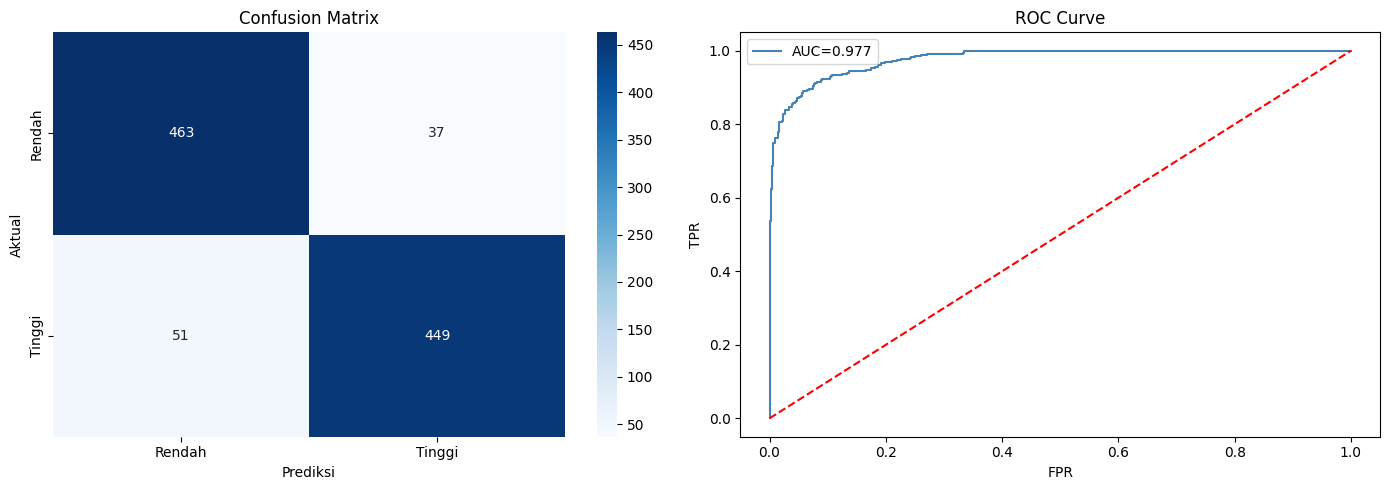

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rendah', 'Tinggi'], yticklabels=['Rendah', 'Tinggi'])
axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('Aktual'); axes[0].set_xlabel('Prediksi')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC={roc_auc_score(y_test,y_prob):.3f}')
axes[1].plot([0,1],[0,1],'r--'); axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

| Metrik | Sangat Baik | Baik | Cukup | Buruk |
|--------|------------|------|-------|-------|
| Accuracy | > 90% | 80–90% | 70–80% | < 70% |
| F1-score | > 0.90 | 0.80–0.90 | 0.70–0.80 | < 0.70 |
| ROC-AUC | > 0.95 | 0.85–0.95 | 0.75–0.85 | < 0.75 |

### Kapan lebih fokus ke Recall vs Precision?
- **Recall penting:** Kita ingin mendeteksi semua mahasiswa yang butuh bantuan (false negative mahal)
- **Precision penting:** Kita ingin menghindari overintervention (false positive mahal)

In [9]:
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy : {acc:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}')

cv = cross_val_score(best_model, X, y, cv=5, scoring='f1')
print(f'CV F1    : {cv.mean():.4f} ± {cv.std():.4f}')

Accuracy : 0.9120
F1-score : 0.9108
ROC-AUC  : 0.9774
CV F1    : 0.9049 ± 0.0079


---
## 7.  Cara Mengoptimasi Model

### Tips Meningkatkan Logistic Regression:
1. **Feature Engineering** — buat rasio: `study_to_social = study_hours / (social_media_hours + 1)`
2. **Threshold tuning** — ubah threshold 0.5 ke nilai yang optimal berdasarkan precision-recall trade-off
3. **Polynomial features** — menangkap interaksi 2 fitur
4. **Handle class imbalance** — `class_weight='balanced'` atau SMOTE

In [10]:
# Threshold tuning
from sklearn.metrics import precision_recall_curve
prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
best_thresh_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_thresh_idx] if best_thresh_idx < len(thresholds) else 0.5

y_pred_opt = (y_prob >= best_thresh).astype(int)
print(f'Default threshold (0.5) F1 : {f1_score(y_test, y_pred):.4f}')
print(f'Optimal threshold ({best_thresh:.3f}) F1: {f1_score(y_test, y_pred_opt):.4f}')

Default threshold (0.5) F1 : 0.9108
Optimal threshold (0.397) F1: 0.9167


---
## 8.  Cara Menyimpan Model

In [11]:
os.makedirs('saved_models', exist_ok=True)
joblib.dump(best_model, 'saved_models/logistic_productivity.pkl')
joblib.dump(list(X.columns), 'saved_models/feature_cols_logistic_prod.pkl')
joblib.dump({'threshold': best_thresh, 'median_score': median_score}, 'saved_models/prod_clf_config.pkl')
print(' Logistic Regression model tersimpan!')

 Logistic Regression model tersimpan!


---
## 9.  Cara Menggunakan Model Hasil Training

In [12]:
loaded = joblib.load('saved_models/logistic_productivity.pkl')
cols   = joblib.load('saved_models/feature_cols_logistic_prod.pkl')
cfg    = joblib.load('saved_models/prod_clf_config.pkl')
print(f'Model dimuat  (threshold={cfg["threshold"]:.3f})')

new_students = pd.DataFrame([
    {'age': 20, 'gender': 1, 'academic_level': 1, 'study_hours': 6, 'self_study_hours': 3,
     'online_classes_hours': 2, 'social_media_hours': 1, 'gaming_hours': 0.5, 'sleep_hours': 7.5,
     'screen_time_hours': 4, 'exercise_minutes': 45, 'caffeine_intake_mg': 100,
     'part_time_job': 0, 'upcoming_deadline': 1, 'internet_quality': 2,
     'mental_health_score': 8, 'focus_index': 7, 'burnout_level': 2},
    {'age': 22, 'gender': 0, 'academic_level': 2, 'study_hours': 1, 'self_study_hours': 0.5,
     'online_classes_hours': 0.5, 'social_media_hours': 6, 'gaming_hours': 4, 'sleep_hours': 5,
     'screen_time_hours': 10, 'exercise_minutes': 5, 'caffeine_intake_mg': 300,
     'part_time_job': 1, 'upcoming_deadline': 0, 'internet_quality': 1,
     'mental_health_score': 4, 'focus_index': 3, 'burnout_level': 7}
])[cols]

pred_proba = loaded.predict_proba(new_students)[:, 1]
pred_class = (pred_proba >= cfg['threshold']).astype(int)

print('\nHasil Prediksi:')
for i, (cls, prob) in enumerate(zip(pred_class, pred_proba)):
    label = ' Produktivitas Tinggi' if cls == 1 else ' Produktivitas Rendah'
    print(f'  Mahasiswa {i+1}: {label} (probabilitas={prob:.2%})')

Model dimuat  (threshold=0.397)

Hasil Prediksi:
  Mahasiswa 1:  Produktivitas Tinggi (probabilitas=99.51%)
  Mahasiswa 2:  Produktivitas Rendah (probabilitas=0.08%)
